<a href="https://colab.research.google.com/github/zhouqiang06/ADVISE/blob/main/ADVISE_Biomass_Model_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Biomass model for Eurasia

This notebook demonstrates an example of the **ADVISE** framework for estimating aboveground biomass (AGB) from tree height (`H_tree`) and diameter at breast height (`DBH`).

*Input data citation:*
Schepaschenko, D., Shvidenko, A., Usoltsev, V. et al. A dataset of forest biomass structure for Eurasia. Sci Data 4, 170070 (2017). https://doi.org/10.1038/sdata.2017.70

The notebook is organized into reproducible stages: environment setup, configuration, preprocessing, DNN optimization, autograd derivatives, observation selection, symbolic regression, and independent validation.


## 1. Environment Setup & Dependencies

In [ ]:
# Run only when the packages are not already installed.
%pip install -q optuna pysr cartopy


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 795.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.2/156.2 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.2/100.2 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 9.6 MB/s eta 0:00:00


In [ ]:
from pathlib import Path
import copy
import time

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
from scipy.stats import gaussian_kde
from sklearn import preprocessing
from sklearn.ensemble import IsolationForest
from sklearn.metrics import r2_score

import optuna
import torch
import torch.nn as nn
import torch.optim as optim
from pysr import PySRRegressor


/usr/local/lib/python3.13/dist-packages/juliacall/__init__.py:61: UserWarning: torch was imported before juliacall. This may cause a segfault. To avoid this, import juliacall before importing torch. For updates, see https://github.com/pytorch/pytorch/issues/78829.
  warnings.warn(


[juliapkg] Found dependencies: /usr/local/lib/python3.13/dist-packages/pysr/juliapkg.json
[juliapkg] Found dependencies: /usr/local/lib/python3.13/dist-packages/juliapkg/juliapkg.json
[juliapkg] Found dependencies: /usr/local/lib/python3.13/dist-packages/juliacall/juliapkg.json
[juliapkg] Locating Julia 1.10.3 - 1.11
[juliapkg] WARNING: You have Julia 1.12.6 installed but 1.10.3 - 1.11 is required.
[juliapkg]   It is recommended that you upgrade Julia or install JuliaUp.
[juliapkg] Querying Julia versions from https://julialang-s3.julialang.org/bin/versions.json
[juliapkg] WARNING: About to install Julia 1.11.9 to /root/.julia/environments/pyjuliapkg/pyjuliapkg/install.
[juliapkg]   If you use juliapkg in more than one environment, you are likely to
[juliapkg]   have Julia installed in multiple locations. It is recommended to
[juliapkg]   install JuliaUp (https://github.com/JuliaLang/juliaup) or Julia
[juliapkg]   (https://julialang.org/downloads) yourself.
[juliapkg] Downloading Julia

## 2. Global Configuration Variables

In [ ]:
# Google Colab only. Uncomment if the data are stored on Google Drive.
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [ ]:
# Keep paths and experiment settings in one place.
DATA_PATH = Path("/content/drive/My Drive/Colab Notebooks/Biomass_tree_DB_2var_model.csv")
VALID_PATH = Path("/content/drive/My Drive/Colab Notebooks/Biomass_tree_DB_2var_validation.csv")
SAVE_PATH = Path("/content/drive/My Drive/Colab Notebooks/Biomass_outputs")
SAVE_PATH.mkdir(parents=True, exist_ok=True)

FEATURE_COLUMNS = ["DBH", "H_tree"]
TARGET_COLUMN = "Pabo"
RANDOM_SEED = 42

N_TRIALS = 50
TRIAL_EPOCHS = 30
FINAL_EPOCHS = 100

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

print(f"Output directory: {SAVE_PATH}")


Output directory: /content/drive/My Drive/Colab Notebooks/Biomass_outputs


/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:263: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:263: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:263: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:263: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


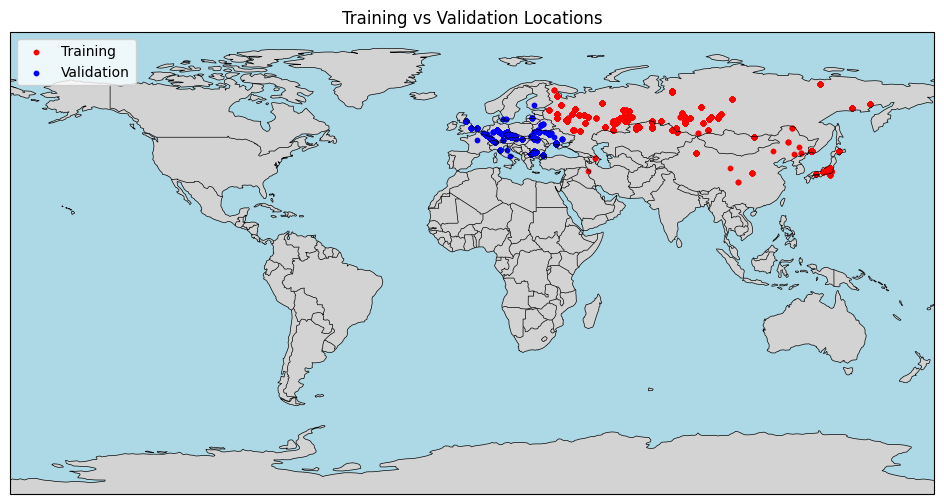

In [ ]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature


# Load your files (replace with actual filenames)
df1 = pd.read_csv(DATA_PATH)
df2 = pd.read_csv(VALID_PATH)


# Create figure
plt.figure(figsize=(12, 6))

# Use PlateCarree projection (standard lon/lat)
ax = plt.axes(projection=ccrs.PlateCarree())

# Add land, oceans, borders, and coastlines
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)

# Set global extent
ax.set_global()

# Plot your points
ax.scatter(df1["Longitude"], df1["Latitude"],
           color="red", s=10, transform=ccrs.PlateCarree(),
           label="Training")

ax.scatter(df2["Longitude"], df2["Latitude"],
           color="blue", s=10, transform=ccrs.PlateCarree(),
           label="Validation")

plt.title("Training vs Validation Locations")
plt.legend()

# Save PNG for GitHub
plt.savefig("static_map.png", dpi=200, bbox_inches="tight")

plt.show()

## 3. Data Preprocessing

In [ ]:
def preprocess_data(
    dataset: pd.DataFrame,
    feature_columns: list[str],
    target_column: str,
    standardize: bool = True,
    train_fraction: float = 0.8,
    min_train: int = 3000,
    random_state: int = 42,
):
    """Shuffle, split, and optionally standardize a regression dataset."""
    data = dataset.loc[:, feature_columns + [target_column]].copy()
    data = data.sample(frac=1, random_state=random_state).reset_index(drop=True)

    n_train = max(int(len(data) * train_fraction), min_train)
    if n_train >= len(data):
        raise ValueError("Training size must be smaller than the dataset size.")

    x_raw = data[feature_columns].to_numpy(dtype=np.float64)
    y = data[target_column].to_numpy(dtype=np.float64)

    scaler = preprocessing.StandardScaler() if standardize else None
    x = scaler.fit_transform(x_raw) if scaler is not None else x_raw.copy()

    return (
        x[:n_train],
        y[:n_train],
        x[n_train:],
        y[n_train:],
        x_raw,
        y,
        scaler,
    )


In [ ]:
dataset = pd.read_csv(DATA_PATH)

(
    train_x_np,
    train_y_np,
    test_x_np,
    test_y_np,
    all_fea_raw,
    y_fea_np,
    scaler,
) = preprocess_data(
    dataset,
    FEATURE_COLUMNS,
    TARGET_COLUMN,
    standardize=True,
    train_fraction=0.8,
    random_state=RANDOM_SEED,
)

var_names = FEATURE_COLUMNS.copy()
all_fea_np = scaler.transform(all_fea_raw)

# Persist data needed by later notebook stages.
np.save(SAVE_PATH / "all_fea.npy", all_fea_np)
np.save(SAVE_PATH / "y_fea.npy", y_fea_np)
np.save(SAVE_PATH / "all_fea_raw.npy", all_fea_raw)
pd.DataFrame(all_fea_raw, columns=var_names).to_csv(
    SAVE_PATH / "all_fea_raw.csv", index=False
)
joblib.dump(scaler, SAVE_PATH / "torch_scaler.bin")

# Convert once and reuse these tensors.
train_x = torch.from_numpy(train_x_np).float()
train_y = torch.from_numpy(train_y_np).float().unsqueeze(1)
test_x = torch.from_numpy(test_x_np).float()
test_y = torch.from_numpy(test_y_np).float().unsqueeze(1)
all_fea = torch.from_numpy(all_fea_np).float()

print(f"Training: X={train_x.shape}, y={train_y.shape}")
print(f"Test:     X={test_x.shape}, y={test_y.shape}")


Training: X=torch.Size([4444, 2]), y=torch.Size([4444, 1])
Test:     X=torch.Size([1111, 2]), y=torch.Size([1111, 1])


## 4. Deep Neural Network Optimization & Training
Defines a dynamic network architecture evaluated dynamically across continuous trails using an Optuna Study.

In [ ]:
class EarlyStopping:
    """Stop training when validation loss stops improving."""

    def __init__(self, patience=5, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = np.inf
        self.best_model_state = None

    def __call__(self, val_loss, model=None):
        improved = val_loss < self.best_loss - self.min_delta

        if improved:
            self.best_loss = val_loss
            self.counter = 0
            if model is not None:
                self.best_model_state = copy.deepcopy(model.state_dict())
        else:
            self.counter += 1

        return self.counter >= self.patience


class RegressionDNN(nn.Module):
    """Fully connected regression network with ReLU hidden layers."""

    def __init__(self, input_dim, hidden_dims):
        super().__init__()
        layers = []
        previous_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.extend([nn.Linear(previous_dim, hidden_dim), nn.ReLU()])
            previous_dim = hidden_dim

        layers.append(nn.Linear(previous_dim, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


train_dataset = torch.utils.data.TensorDataset(train_x, train_y)


def objective(trial):
    """Optuna objective function."""
    num_layers = trial.suggest_int("num_layers", 1, 10)
    hidden_dims = [
        trial.suggest_int(f"units_layer_{i}", 16, 512)
        for i in range(num_layers)
    ]

    learning_rate = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)

    loader = torch.utils.data.DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True
    )
    model = RegressionDNN(train_x.shape[1], hidden_dims)
    optimizer = optim.Adam(
        model.parameters(), lr=learning_rate, weight_decay=weight_decay
    )
    criterion = nn.MSELoss()
    early_stopping = EarlyStopping(patience=5)

    for epoch in range(TRIAL_EPOCHS):
        model.train()
        for batch_x, batch_y in loader:
            optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(batch_x), batch_y)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(test_x), test_y).item()

        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        if early_stopping(val_loss):
            break

    return early_stopping.best_loss


[I 2026-10-05 18:41:44,061] A new study created in memory with name: no-name-f3d742b8-23c2-4815-a381-d5f93f1a7355
[I 2026-10-05 18:41:57,885] Trial 0 finished with value: 1174.5286865234375 and parameters: {'num_layers': 7, 'units_layer_0': 440, 'units_layer_1': 153, 'units_layer_2': 379, 'units_layer_3': 479, 'units_layer_4': 135, 'units_layer_5': 117, 'units_layer_6': 312, 'lr': 0.0031587387235457102, 'batch_size': 64, 'weight_decay': 0.005622616782922459}. Best is trial 0 with value: 1174.5286865234375.
[I 2026-10-05 18:42:19,191] Trial 1 finished with value: 1127.875 and parameters: {'num_layers': 10, 'units_layer_0': 181, 'units_layer_1': 344, 'units_layer_2': 465, 'units_layer_3': 126, 'units_layer_4': 402, 'units_layer_5': 107, 'units_layer_6': 309, 'units_layer_7': 406, 'units_layer_8': 427, 'units_layer_9': 257, 'lr': 0.007460047314143829, 'batch_size': 64, 'weight_decay': 0.002015732255134183}. Best is trial 1 with value: 1127.875.
[I 2026-10-05 18:42:22,239] Trial 2 finished

Best validation loss: 1127.88
Best architecture: [181, 344, 465, 126, 402, 107, 309, 406, 427, 257]
Best parameters: {'num_layers': 10, 'units_layer_0': 181, 'units_layer_1': 344, 'units_layer_2': 465, 'units_layer_3': 126, 'units_layer_4': 402, 'units_layer_5': 107, 'units_layer_6': 309, 'units_layer_7': 406, 'units_layer_8': 427, 'units_layer_9': 257, 'lr': 0.007460047314143829, 'batch_size': 64, 'weight_decay': 0.002015732255134183}
Final R²: 0.9498
Final RMSE: 34.0687


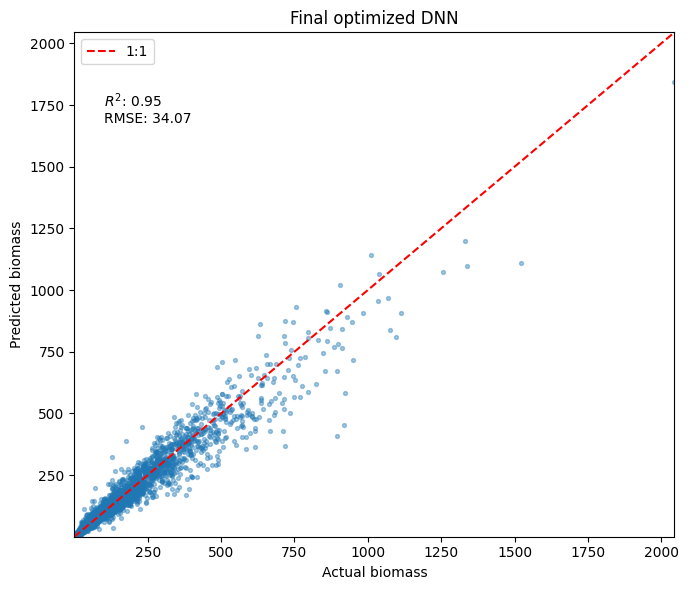

In [ ]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=N_TRIALS)

best_params = study.best_trial.params
best_hidden_dims = [
    best_params[f"units_layer_{i}"]
    for i in range(best_params["num_layers"])
]

print(f"Best validation loss: {study.best_value:.6g}")
print(f"Best architecture: {best_hidden_dims}")
print(f"Best parameters: {best_params}")

final_model = RegressionDNN(train_x.shape[1], best_hidden_dims)
optimizer = optim.Adam(
    final_model.parameters(),
    lr=best_params["lr"],
    weight_decay=best_params["weight_decay"],
)
criterion = nn.MSELoss()

final_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=best_params["batch_size"],
    shuffle=True,
)

for epoch in range(FINAL_EPOCHS):
    final_model.train()
    for batch_x, batch_y in final_loader:
        optimizer.zero_grad(set_to_none=True)
        loss = criterion(final_model(batch_x), batch_y)
        loss.backward()
        optimizer.step()

checkpoint = {
    "hidden_dims": best_hidden_dims,
    "state_dict": final_model.state_dict(),
    "hyperparameters": best_params,
}
torch.save(checkpoint, SAVE_PATH / "final_regression_model.pt")

# Compute predictions once and reuse them for evaluation and autograd.
final_model.eval()
input_data = all_fea.detach().clone().requires_grad_(True)
predictions = final_model(input_data)
pred_np = predictions.detach().cpu().numpy().squeeze()
np.save(SAVE_PATH / "predictions.npy", pred_np)

r_squared = r2_score(y_fea_np, pred_np)
rmse = np.sqrt(np.mean((y_fea_np - pred_np) ** 2))
print(f"Final R²: {r_squared:.4f}")
print(f"Final RMSE: {rmse:.4f}")

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_fea_np, pred_np, alpha=0.4, s=8)
lims = [min(y_fea_np.min(), pred_np.min()), max(y_fea_np.max(), pred_np.max())]
ax.plot(lims, lims, "r--", label="1:1")
ax.set(xlabel="Actual biomass", ylabel="Predicted biomass",
       title="Final optimized DNN", xlim=lims, ylim=lims)
ax.annotate(
    f"$R^2$: {r_squared:.2f}\nRMSE: {rmse:.2f}",
    xy=(0.05, 0.82), xycoords="axes fraction",
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"),
)
ax.legend()
fig.tight_layout()
fig.savefig(SAVE_PATH / "dnn_performance.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)


## 5. Feature Attribution Analysis
Runs feature sensitivity profiles using continuous gradient tracking engines.

In [ ]:
start_time = time.perf_counter()

gradients_scaled = torch.autograd.grad(
    outputs=predictions,
    inputs=input_data,
    grad_outputs=torch.ones_like(predictions),
    retain_graph=False,
    create_graph=False,
)[0].detach().cpu().numpy()

# If x_scaled = (x_raw - mean) / std, then
# d(y)/d(x_raw) = d(y)/d(x_scaled) / std.
gradients_unscaled = (
    gradients_scaled / scaler.scale_
    if scaler is not None
    else gradients_scaled
)

print(f"Autograd time: {time.perf_counter() - start_time:.3f} s")

np.save(SAVE_PATH / "autograd_scaled.npy", gradients_scaled)
np.save(SAVE_PATH / "autograd_unscaled.npy", gradients_unscaled)
torch.save(final_model.state_dict(), SAVE_PATH / "model_state.pth")


Autograd time: 0.710 s


## 6. Plot variable contributions and partial derivatives to select training data for symbolic regression.

---

Conclusion: The contribution plots indicate a functional relationship between AGB and DBH, whereas tree height (H_tree) provides minimal predictive contribution. For higher values, scatter increases across both plots, indicating that the uniform relationship becomes less pronounced at the upper range. Thus, we will only use data with (DBH<25) and (partial derivative !=0) for symbolic regression.

In [ ]:
def density_scatter(ax, x, y, xlabel, ylabel, point_size=3):
    """Scatter plot colored by 2-D kernel density."""
    xy = np.vstack([x, y])
    density = gaussian_kde(xy)(xy)
    ax.scatter(x, y, s=point_size, alpha=0.4, c=density)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)


def plot_feature_relationships(
    feature_values,
    values,
    variable_names,
    y_label_template,
    save_path=None,
):
    """Plot each variable against a corresponding contribution/derivative."""
    n_features = feature_values.shape[1]
    fig, axes = plt.subplots(
        1, n_features, figsize=(5 * n_features, 4), squeeze=False
    )
    axes = axes.ravel()

    for i, ax in enumerate(axes):
        density_scatter(
            ax,
            feature_values[:, i],
            values[:, i],
            variable_names[i],
            y_label_template.format(variable=variable_names[i]),
        )

    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=400, bbox_inches="tight")
    plt.show()
    plt.close(fig)


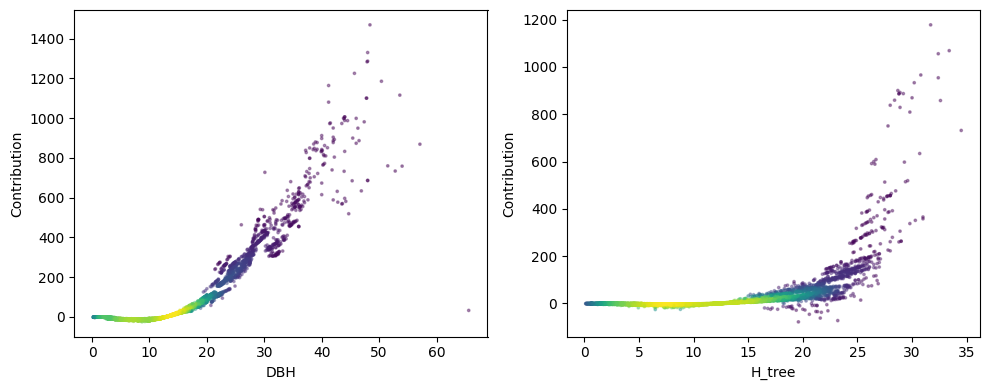

In [ ]:
# For standardized x, contribution = (dy/dx_scaled) * x_scaled.
autocontr = gradients_scaled * all_fea_np

plot_feature_relationships(
    all_fea_raw,
    autocontr,
    var_names,
    y_label_template="Contribution",
    save_path=SAVE_PATH / "variable_contributions.png",
)


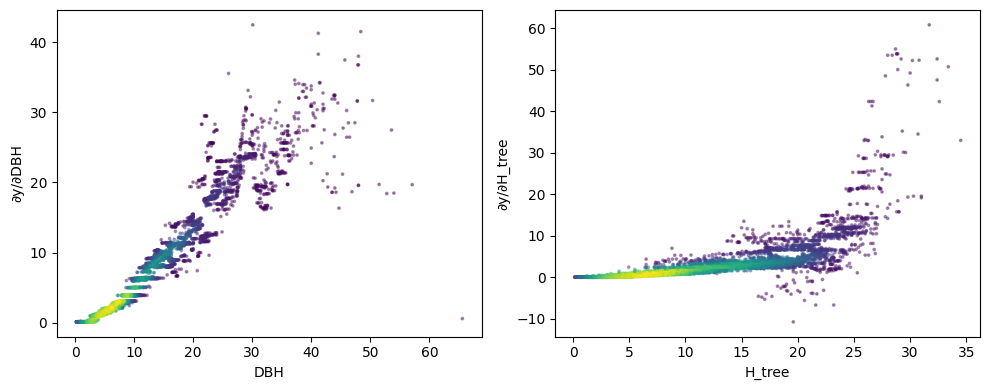

In [ ]:
plot_feature_relationships(
    all_fea_raw,
    gradients_unscaled,
    var_names,
    y_label_template="∂y/∂{variable}",
    save_path=SAVE_PATH / "partial_derivatives.png",
)


# 7. Outlier detection

---
We further exclude outliers for symbolic regression


In [ ]:
outlier_features = np.column_stack((all_fea_raw[:, 0], autocontr[:, 0]))

isolation_forest = IsolationForest(
    contamination=0.10,
    random_state=RANDOM_SEED,
)
outlier_labels = isolation_forest.fit_predict(outlier_features)

np.save(SAVE_PATH / "IsolationForest_filter.npy", outlier_labels)

fit_idx = (
    (outlier_labels == 1)
    & np.all(gradients_unscaled != 0, axis=1)
    & (all_fea_raw[:, 0] < 25)
)

print(f"Selected observations: {fit_idx.sum():,}")
print(f"Excluded observations: {(~fit_idx).sum():,}")


Selected observations: 4,835
Excluded observations: 720


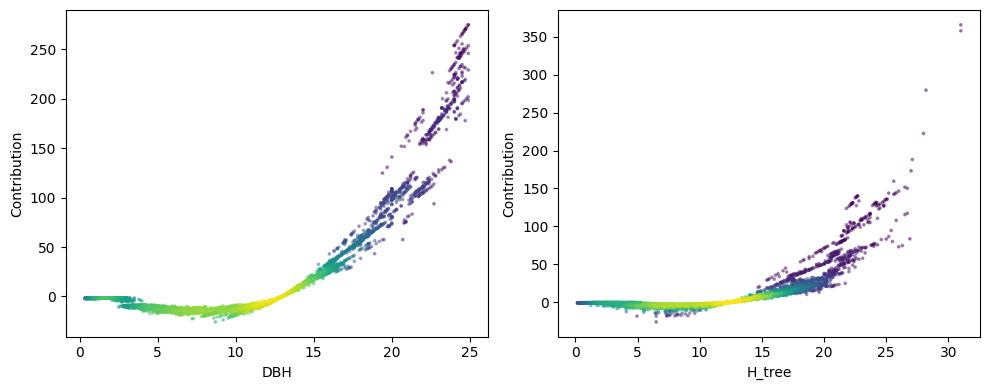

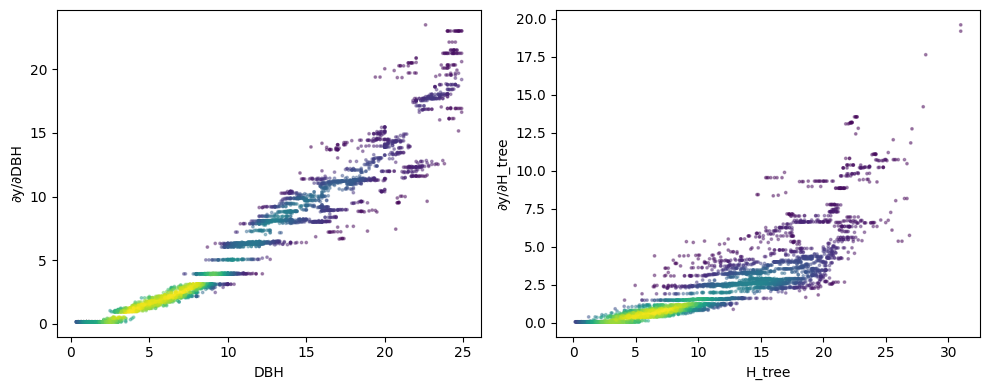

In [ ]:
plot_feature_relationships(
    all_fea_raw[fit_idx],
    autocontr[fit_idx],
    var_names,
    y_label_template="Contribution",
    save_path=SAVE_PATH / "selected_variable_contributions.png",
)

plot_feature_relationships(
    all_fea_raw[fit_idx],
    gradients_unscaled[fit_idx],
    var_names,
    y_label_template="∂y/∂{variable}",
    save_path=SAVE_PATH / "selected_partial_derivatives.png",
)


## 8. Analytical Validation using Symbolic Regression

---
Distinct clustering in the training data suggests multiple potential functional forms for $\text{AGB} \sim \text{DBH} + \text{H}_{\text{tree}}$, though it could also due to DNN underfitting. To derive explicit equation models, we considered two options: (a) fitting separate equations to each individual cluster, or (2) fitting a single global equation to the entire training dataset to capture the overall driving mechanisms. We chose the global approach, as species-specific coefficient optimization can be applied later (similar to tranditional modeling). Furthermore, allowing the DNN to arbitrarily dictate cluster assignments undermines scientific interpretability.

In [ ]:
def preprocessing_sr(data_path:str, standerize=True, use_dnn_pred=False,train_portion=0.8, min_train=3000):
    """Preprocessing the simulated data for symbolic regression.

    Args:
        data_path (str): Path to the directory containing input data files.
        standerize (bool, optional): If standerize X variables. Defaults to True.
        use_dnn_pred (bool, optional): If use DNN predictions as the target features. Defaults to False.
        train_portion (float, optional): split training test data. Defaults to 0.8.
        min_train (int, optional): minimum number of training data. Defaults to 3000.

    Returns:
        var_names (Index): Column names of the input features.
        train_x (array): Preprocessed X training data
        train_y (array): Preprocessed Y training data
        test_x (array): Preprocessed X test data
        test_y (array): Preprocessed Y test data
        scaler (object): The standardization scaler (see sklearn.preprocessing.StandardScaler)
    """
    # df_slope = np.load(os.path.join(data_path, 'autograd_unscaled.npy'))
    x_df = pd.read_csv(os.path.join(data_path, f'all_fea_raw.csv'))

    # fit_idx = (df_slope[:, 0] < 30) & (df_slope[:, 1] < 20)
    fit_idx = filter_index()
    print(f"fit_idx: {np.sum(fit_idx)}")
    x_df = x_df.iloc[fit_idx]
    var_names = x_df.columns
    x_stack = x_df.to_numpy()
    print('x_stack.shape: ', x_stack.shape) # x_stack.shape:  (260388, 15)
    if use_dnn_pred:
        y_var = np.load(os.path.join(data_path, f'predictions.npy'))[fit_idx]
    else:
        y_var = np.load(os.path.join(data_path, f'y_fea.npy'))[fit_idx]
    suf_idx = np.arange(x_stack.shape[0])
    np.random.shuffle(suf_idx)
    x_stack = x_stack[suf_idx, :]
    y_var = y_var[suf_idx]
    n_training = max(int(x_stack.shape[0] * train_portion), min_train)
    print('n_training: ', n_training)
    if standerize:
        scaler = joblib.load(os.path.join(data_path, "torch_scaler.bin"))
        x_stack = scaler.fit_transform(x_stack)

    else:
        scaler = None

    train_x = x_stack[:n_training, :].copy()
    train_y = y_var[:n_training].copy()

    test_x = x_stack[n_training:, :].copy()
    test_y = y_var[n_training:].copy()
    print(train_x.shape, train_y.shape, test_x.shape, test_y.shape)
    return var_names, train_x, train_y, test_x, test_y, scaler


def fit_PySRRegressor(data_path: str, sub_folder: str, standerize=False, use_dnn_pred=False, train_portion=0.1, min_train=200):
    """Fit a PySR (symbolic regression) model to the preprocessed data.

    Args:
        data_path (str): Path to the directory containing input data files.
        sub_folder (str): Subdirectory name where the model outputs will be saved.
        standerize (bool, optional): Whether to standardize X variables. Defaults to False.
        use_dnn_pred (bool, optional): Whether to use DNN predictions as target. Defaults to False.
        train_portion (float, optional): Proportion of data to use for training. Defaults to 0.1.
        min_train (int, optional): Minimum number of training samples. Defaults to 200.

    Returns:
        None. Saves the fitted model to the specified output directory.
    """
    var_names, train_x, train_y, _, _, _ = preprocessing_sr(data_path=data_path, standerize=standerize, use_dnn_pred=use_dnn_pred, train_portion=train_portion, min_train=min_train)
    df = pd.DataFrame(data=train_x, columns=var_names)
    if not os.path.exists(os.path.join(data_path, sub_folder)):
        os.makedirs(os.path.join(data_path, sub_folder))
    df['response'] = train_y

    dt_str = datetime.now().strftime("%Y%m%dT%H%M%S")

    model = PySRRegressor(
        niterations=20000,  # < Increase me for better results; used 10000 in manuscript analysis, but it takes many hours to complete
        maxsize=30, # Max complexity of an equation.  Default is `20`.
        binary_operators=["+", "-", "*", "/", "^"],
        unary_operators=[
            "exp",
            "log",
        ],
        guesses=["exp(-2.409 + 0.9522 * log(0.239 * DBH*DBH * H_tree))", "0.0673*(0.5*DBH*DBH*H_tree)^0.976"], # (optional) classical model as start (https://doi.org/10.1111/gcb.12629 and https://doi.org/10.1007/s00442-005-0100-x)
        output_directory=os.path.join(data_path, sub_folder)
    )

    model.fit(df.drop(['response'], axis=1), df['response'])


def load_model(eq_path: str):
    """Load a PySR model from a saved directory.

    Args:
        eq_path (str): Path to the directory containing the saved PySR model.

    Returns:
        PySRRegressor: The loaded PySR model object.
    """
    return PySRRegressor.from_file(run_directory=eq_path) # model


def eval_eq_str_slope(model, eq_idx:int, df_x, df_slope, valid_idx, step=0.0001, slope_out=None, include_unused_variables=False)->float:
    """Evaluate the partial derivative loss of a specific equation from the PySR model.

    This function computes numerical gradients for each input variable and compares them
    to the reference gradients (df_slope) to calculate a normalized RMSE loss.

    Args:
        model (PySRRegressor): The fitted PySR model.
        eq_idx (int): Index of the equation in the model's hall of fame to evaluate.
        df_x (DataFrame): Input features dataframe.
        df_slope (array): Reference gradients/slopes for comparison.
        valid_idx (array): Boolean array indicating which samples to use for validation.
        step (float, optional): Step size for numerical gradient computation. Defaults to 0.0001.
        slope_out (str, optional): Path to save computed slopes as CSV. Defaults to None.
        include_unused_variables (bool, optional): Whether to penalize unused variables. Defaults to False.

    Returns:
        float: Average normalized RMSE of partial derivatives across all variables, or None if no variables are used.
    """
    # model = load_model(eq_path)
    # print(model.equations_.sympy_format[eq_idx])
    eq_slope = df_x.copy()
    loss_der = []
    for n in range(len(df_x.columns)):
        df_x.iloc[:, n] -= step
        pred_pre = model.predict(df_x, eq_idx)
        df_x.iloc[:, n] += 2 * step
        pred_pos = model.predict(df_x, eq_idx)
        df_x.iloc[:, n] -= step
        df_y = model.predict(df_x, eq_idx)

        if (sum(abs(pred_pre-df_y))!=0) | (sum(abs(df_y-pred_pos))!=0): # variable used in equation
            der = (pred_pos - pred_pre)/(2*step)
            eq_slope.iloc[:, n] = der
            diffs = der[valid_idx] - df_slope[valid_idx, n]
            rmse_der = np.sqrt(sum(diffs ** 2) / len(diffs)) / np.std(df_slope[valid_idx, n]) # np.std(df_x.iloc[:, n])
            loss_der.append(rmse_der)
        elif include_unused_variables and (sum(abs(pred_pre-df_y))==0) & (sum(abs(df_y-pred_pos))==0):
            rmse_der = np.sqrt(sum((df_slope[valid_idx, n]) ** 2) / np.sum(valid_idx)) / np.std(df_slope[valid_idx, n])
            loss_der.append(rmse_der)
        else:
            eq_slope.iloc[:, n] *= 0
    if slope_out:
        eq_slope.to_csv(slope_out)

    if len(loss_der) == 0:
        return None
    return sum(loss_der) /len(loss_der)


def eval_PySRRegressor(model_dir: str, sub_folder: str, include_unused_variables=False):
    """Evaluate all equations from PySR models and select the best one using ADVISE loss.

    This function loads all PySR models from the specified directory, evaluates each equation
    using both the PySR score and the ADVISE loss (combination of RMSE and partial derivative loss),
    and saves a summary of all models along with the final recommended equations.

    Args:
        model_dir (str): Path to the directory containing the data and model outputs.
        sub_folder (str): Subdirectory name where PySR models are stored.
        include_unused_variables (bool, optional): Whether to penalize equations that don't use all variables. Defaults to False.

    Returns:
        None. Saves evaluation results to CSV files:
            - model_summary.csv: Summary of all evaluated equations
            - final_eq.csv: Best equations selected by PySR and ADVISE methods
    """

    eq_files = glob(os.path.join(model_dir, sub_folder, "*/"), recursive=True)
    if len(eq_files)==0:
        print(f"eval_PySRRegressor: No equation found in {model_dir} {sub_folder}")
        return

    df = pd.read_csv(os.path.join(model_dir, 'all_fea_raw.csv')).dropna()

    df_slope = np.load(os.path.join(model_dir, 'autograd_unscaled.npy'))
    train_y = np.load(os.path.join(model_dir, 'y_fea.npy')).squeeze()
    dnn_pred = np.load(os.path.join(model_dir, 'predictions.npy')).flatten()
    fit_idx = filter_index()

    df.iloc[fit_idx].to_csv(os.path.join(SAVE_PATH, 'eval_PySRRegressor_test_input.csv'), index=False)
    model_eval = []
    model_index = 0
    for m in eq_files:
        if not os.path.exists(os.path.join(m, "hall_of_fame.csv")):
            continue
        model = load_model(m)

        for i in range(len(model.equations_)):
            mad = np.mean(np.abs(model.predict(df, i) - train_y))
            rmse_std = np.sqrt(np.mean((model.predict(df, i) - train_y)**2)) / np.std(train_y)
            loss_partial = eval_eq_str_slope(model, i, df, df_slope, fit_idx, include_unused_variables=include_unused_variables)
            if loss_partial is None:
                model_eval.append({"model_path": m, "model_index": model_index, "Complexity": model.equations_.complexity[i], "Equation": model.equations_.sympy_format[i], "ADVISE_loss": None, "PySR_Score": model.equations_.score[i]})
            else:
                model_eval.append({"model_path": m, "model_index": model_index, "Complexity": model.equations_.complexity[i], "Equation": model.equations_.sympy_format[i], "ADVISE_loss": (loss_partial + rmse_std), "PySR_Score": model.equations_.score[i]})
            model_index += 1
    df_model_eval = pd.DataFrame(model_eval)
    df_model_eval.to_csv(os.path.join(model_dir, sub_folder, f"model_summary.csv"))

    # determine the percision of DNN model prediction. We will apply this precision threshold to round ADVISE_loss, preventing the selection of over-parameterized models that yield only marginal loss reductions.
    mad = np.min(np.abs((dnn_pred - train_y)))
    fractional_part = f"{mad:f}".split('.')[1]
    precision_position = len(fractional_part) - len(fractional_part.lstrip('0')) + 1
    print(precision_position, " precision_position")

    df_model_eval_sort = df_model_eval.sort_values(by='PySR_Score', ascending=False)
    max_score = df_model_eval_sort["PySR_Score"].idxmax()
    df_model_eval_sort['ADVISE_loss'] = df_model_eval_sort['ADVISE_loss'].round(precision_position)
    min_new = df_model_eval_sort["ADVISE_loss"].idxmin()
    print(f"pySR: {df_model_eval_sort.loc[max_score]}")
    print(f"ADVISE: {df_model_eval_sort.loc[min_new]}")
    org_model = df_model_eval_sort.loc[max_score]["Equation"]
    new_model = df_model_eval_sort.loc[min_new]["Equation"]
    rec = pd.DataFrame([{"pySR": org_model, "ADVISE": new_model}])
    rec.to_csv(os.path.join(model_dir, sub_folder, "final_eq.csv"), index=False)


from sklearn.ensemble import IsolationForest
def filter_index():
    """Filter data indices to remove outliers and invalid samples using Isolation Forest.

    This function applies Isolation Forest anomaly detection on the feature contributions
    and gradients, then applies additional filtering criteria to identify valid samples.

    Returns:
        array: Boolean array indicating which samples pass the filtering criteria.
            Samples are included if they:
            - Are classified as inliers by Isolation Forest
            - Have non-zero gradients in the first two dimensions
            - Have the first raw feature value less than 25
    """
    all_fea_raw = np.load(os.path.join(SAVE_PATH, "all_fea_raw.npy"))
    all_fea_np = np.load(os.path.join(SAVE_PATH, "all_fea.npy"))
    scaler = joblib.load(os.path.join(SAVE_PATH, "torch_scaler.bin"))
    gradients_unscaled = np.load(os.path.join(SAVE_PATH, "autograd_unscaled.npy"))
    autocontr = gradients_unscaled * all_fea_np * scaler.scale_
    # data = np.column_stack((autocontr, gradients_unscaled))
    data = np.column_stack((all_fea_raw[:, 0], autocontr[:, 0]))
    # data = autocontr

    # Initialize the model, expecting 10% outliers
    model = IsolationForest(contamination=0.1, random_state=42)

    # Fit and predict (returns 1 for inliers, -1 for outliers)
    predictions = model.fit_predict(data)

    fit_idx = (predictions==1) & (gradients_unscaled[:, 0] != 0) & (gradients_unscaled[:, 1] != 0) & (all_fea_raw[:, 0] < 25)
    return fit_idx

### Run symbolic regression

These operations can take hours, so they remain commented out by default.
To avoid losing progress if Google Colab times out, it is recommended to download all DNN output files and run the symbolic regression analysis locally.

```python
# fit_PySRRegressor(
#     data_path=SAVE_PATH,
#     sub_folder="pySR",
#     train_portion=0.8,
#     min_train=2000,
# )
# summary = eval_PySRRegressor(SAVE_PATH, "pySR", include_unused_variables=True)
# final_eq = extract_final_eq(SAVE_PATH, "pySR")
# display(final_eq)
```


## 9. Equation-model evaluation

The independent validation dataset is used to compare the established allometric model, the DNN, PySR, and ADVISE parameterizations.

*Allometric model citation:*
*Chave, J., Réjou‐Méchain, M., Búrquez, A., Chidumayo, E., Colgan, M.S., Delitti, W.B., Duque, A., Eid, T., Fearnside, P.M., Goodman, R.C. and Henry, M., 2014. Improved allometric models to estimate the aboveground biomass of tropical trees. Global change biology, 20(10), pp.3177-3190.*

Conclusion: ADVISE outperformed both the default DNN and PySR models in terms of $R^2$, RMSE, and Mean Error. While the allometric model demonstrated similar $R^2$ and RMSE values to ADVISE, its Mean Error was substantially larger, suggesting potential prediction bias in the allometric model.


(4444, 2) (4444,)
Allometric_opt: [-3.74543417  0.91774471  1.80487443]
pysr_opt: [1.7342459]
y_pred_advise: (883,)
advise_opt: [0.24705098 1.00660001 1.02281263]


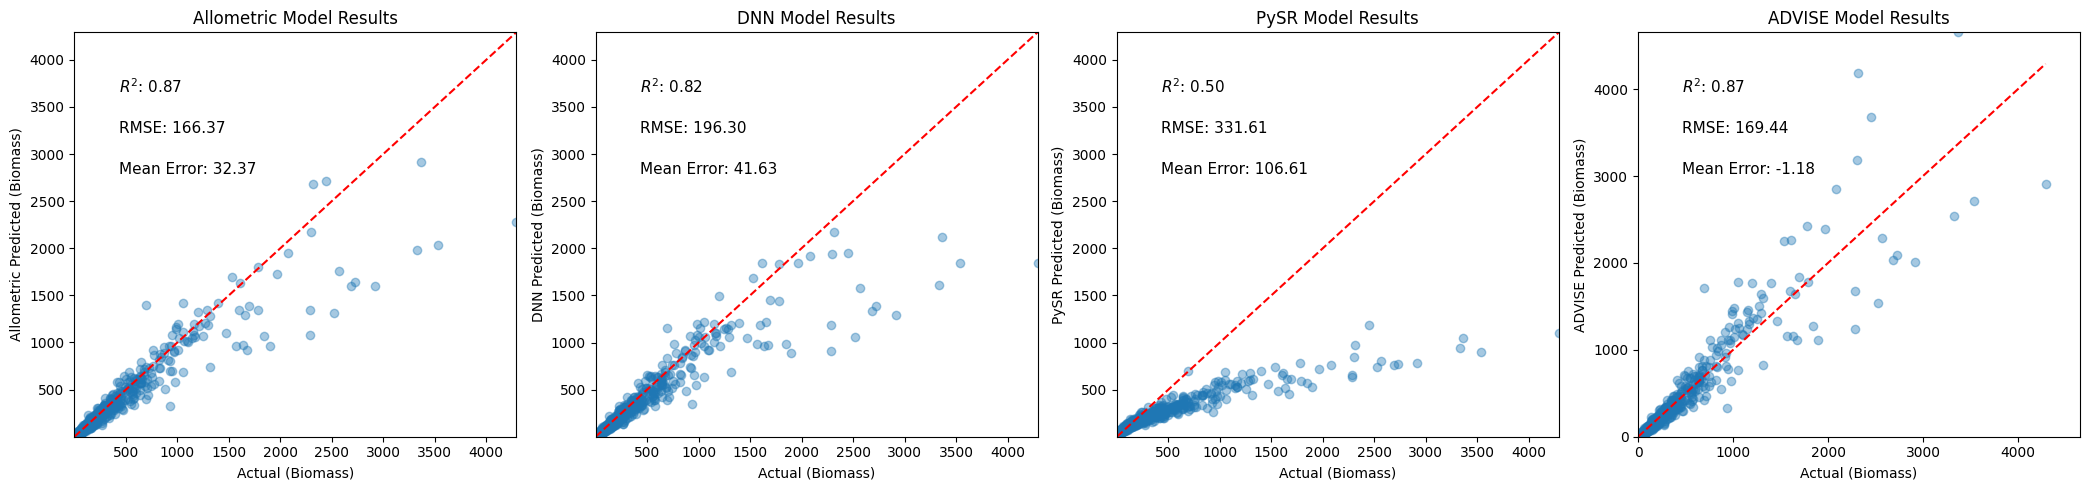

In [ ]:
from scipy.optimize import curve_fit

# =============================================================================
# Define Model Functions
# =============================================================================

def advise_function(x, a, b, c):
    """
    ADVISE biomass prediction function.
    Original: 0.15474962*DBH*(-0.9183737**DBH + 1.0450059**H_tree*DBH)
    """
    DBH, H_tree = x[:, 0], x[:, 1]
    return 0.15474962*DBH*(-0.9183737**DBH + 1.0450059**H_tree*DBH)

def pysr_function(x, a):
    """
    PySR biomass prediction function.
    Original: DBH**1.6492867
    """
    DBH, H_tree = x[:, 0], x[:, 1]
    return DBH**1.6492867

def Allometric_function(x, a, b, c):
    """
    Allometric biomass model.
    Original: exp(a + b * ln(c * DBH**2 * H_tree))
    """
    return np.exp(a + b * np.log(c * x[:, 0]**2 * x[:, 1]))


# =============================================================================
# Load Validation Data
# =============================================================================

dataset_valid = pd.read_csv(VALID_PATH)[["DBH", "H_tree", "Pabo"]]
x_valid = dataset_valid[["DBH", "H_tree"]].to_numpy()
y_valid = dataset_valid["Pabo"].to_numpy()

print(train_x_np.shape, train_y_np.shape)
# =============================================================================
# Perform Regression Fits
# =============================================================================
initial_guess = [-2.409, 0.9522, 0.5]
Allometric_opt, Allometric_cov = curve_fit(
    Allometric_function,
    scaler.inverse_transform(train_x_np),
    train_y_np,
    p0=initial_guess,
    maxfev=50000
)

# =============================================================================
# Function for Plotting
# =============================================================================

def plot_model_comparison(ax, y_valid, y_pred, model_name):
    """Create a diagnostic scatter plot comparing actual vs predicted values."""
    # Calculate metrics
    r_squared = r2_score(y_valid, y_pred)
    rmse = np.sqrt(np.mean((y_valid - y_pred)**2))
    me = np.mean(y_valid - y_pred)

    # Determine axis limits
    val_max = max(np.max(y_valid), np.max(y_pred))
    val_min = min(np.min(y_valid), np.min(y_pred))

    # Create scatter plot
    ax.scatter(y_valid, y_pred, alpha=0.4)
    ax.plot([y_valid.min(), y_valid.max()],
            [y_valid.min(), y_valid.max()],
            'r--', label="1:1 line")

    # Add annotations
    bbox_props = dict(facecolor='white', alpha=0.3, edgecolor='none')
    ax.annotate(f"$R^2$: {r_squared:.2f}",
                xy=(0.1, 0.85), xycoords='axes fraction',
                fontsize=11, bbox=bbox_props)
    ax.annotate(f"RMSE: {rmse:.2f}",
                xy=(0.1, 0.75), xycoords='axes fraction',
                fontsize=11, bbox=bbox_props)
    ax.annotate(f"Mean Error: {me:.2f}",
                xy=(0.1, 0.65), xycoords='axes fraction',
                fontsize=11, bbox=bbox_props)

    # Set labels and limits
    ax.set_xlabel('Actual (Biomass)')
    ax.set_ylabel(f'{model_name} Predicted (Biomass)')
    ax.set_xlim(val_min, val_max)
    ax.set_ylim(val_min, val_max)
    ax.set_title(f'{model_name} Model Results')


# =============================================================================
# Generate Model Predictions and Visualizations
# =============================================================================

fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(21, 5))

# --- Established Model ---
y_pred_pysr = Allometric_function(x_valid, *Allometric_opt)
plot_model_comparison(axs[0], y_valid, y_pred_pysr, 'Allometric')
print(f"Allometric_opt: {Allometric_opt}")
# print(y_valid, y_pred_pysr)
# --- DNN Model ---
input_valid = torch.from_numpy(scaler.transform(x_valid)).float()
input_valid = input_valid.clone().detach().requires_grad_(True)
predictions = final_model(input_valid)
y_pred_dnn = predictions.detach().numpy().squeeze()
plot_model_comparison(axs[1], y_valid, y_pred_dnn, 'DNN')

# --- PySR Model ---
y_pred_pysr = pysr_function(x_valid, *pysr_opt)
plot_model_comparison(axs[2], y_valid, y_pred_pysr, 'PySR')
print(f"pysr_opt: {pysr_opt}")
# --- ADVISE Model ---
y_pred_advise = advise_function(x_valid, *advise_opt)
print(f"y_pred_advise: {y_pred_advise.shape}")
plot_model_comparison(axs[3], y_valid, y_pred_advise, 'ADVISE')
print(f"advise_opt: {advise_opt}")
plt.tight_layout()
plt.show()